ClinicalTrials.gov for trial availability

CDI for disease burden

Census/state population data for normalization

### Data Preparation

#### Process Clinical Trials Data

In [14]:
# imports list
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# process clinical trial data
# read in the data
ct_raw = pd.read_csv('C:\\Dashboard\\DSCI 510\\Project\\Project_Repository_Yogita_Mutyala\\data\\raw\\clinical_trials_us.csv')
print(ct_raw.columns)
ct_raw.head()

Index(['search_condition', 'nct_id', 'title', 'conditions',
       'recruitment_status', 'locations_raw'],
      dtype='object')


,search_condition,nct_id,title,conditions,recruitment_status,locations_raw
0,diabetes,NCT06348160,"iHERO Study: Insurance, Health and Economic Re...",Type 1 Diabetes,ACTIVE_NOT_RECRUITING,"[{""facility"": ""Children's Hospital Los Angeles..."
1,breast cancer,NCT05073172,StrataXRT for the Prevention and Treatment of ...,Breast Carcinoma; Head and Neck Carcinoma; Rad...,WITHDRAWN,"[{""facility"": ""OHSU Knight Cancer Institute"", ..."
2,prostate cancer,NCT02615067,Study to Evaluate 99mTc-MIP-1404 SPECT/CT Imag...,Prostate Cancer,COMPLETED,"[{""facility"": ""City of Hope Cancer Center"", ""c..."
3,lung cancer,NCT01586858,Rituximab for ANCA-associated Vasculitis (RAVE...,Granulomatosis With Polyangiitis; Microscopic ...,TERMINATED,"[{""facility"": ""University of Alabama"", ""city"":..."
4,lung cancer,NCT00501319,Measurement of Pain and Other Symptoms of Non-...,Lung Cancer,COMPLETED,"[{""facility"": ""UT MD Anderson Cancer Center"", ..."


In [16]:
# Parse location_raw
import json
def parse_locations(x):
    try:
        return json.loads(x)
    except:
        return []
ct_raw['locations_parsed'] = ct_raw['locations_raw'].apply(parse_locations)
# explode locations
ct_raw_expanded = ct_raw.explode('locations_parsed')
# extract fields: city,state,facility and country
ct_raw_expanded['city'] = ct_raw_expanded['locations_parsed'].apply(lambda x: x.get('city', None) if isinstance(x, dict) else None)
ct_raw_expanded['state'] = ct_raw_expanded['locations_parsed'].apply(lambda x: x.get('state', None) if isinstance(x, dict) else None)
ct_raw_expanded['facility'] = ct_raw_expanded['locations_parsed'].apply(lambda x: x.get('facility', None) if isinstance(x, dict) else None)
ct_raw_expanded['country'] = ct_raw_expanded['locations_parsed'].apply(lambda x: x.get('country', None) if isinstance(x, dict) else None)
# keep only US locations
ct_raw_expanded = ct_raw_expanded[ct_raw_expanded['country'] == 'United States']
# clean state names (remove leading/trailing whitespace) and filter out rows with invalid characters in search_condition
ct_raw_expanded['state'] = ct_raw_expanded['state'].str.strip()
ct_raw_clean = ct_raw_expanded[~ct_raw_expanded["search_condition"].str.contains(r"[{}:\[\]\"]", regex=True, na=False)]



In [17]:
# disease mapping
disease_map = {
    "diabetes": "Diabetes",
    "breast cancer": "Cancer",
    "prostate cancer": "Cancer",
    "lung cancer": "Cancer",
    "hypertension": "Cardiovascular Disease",
    "stroke": "Cardiovascular Disease",
    "heart failure": "Cardiovascular Disease",
    "heart disease": "Cardiovascular Disease",
    "alzheimer disease": "Cognitive Health and Caregiving",
    "parkinson disease": "Cognitive Health and Caregiving",
    "asthma": "Asthma",
    "depression": "Mental Health",
    "anxiety": "Mental Health",
    "arthritis": "Arthritis",
    "copd": "Chronic Obstructive Pulmonary Disease",
    "chronic obstructive pulmonary disease": "Chronic Obstructive Pulmonary Disease",
    "chronic kidney disease": "Chronic Kidney Disease",
    "obesity": "Nutrition, Physical Activity, and Weight Status",
    "covid-19": None
}

def map_disease(search_condition):
    s = str(search_condition).lower().strip()
    for key, group in disease_map.items():
        if key in s:
            return group
    return None

ct_raw_clean["disease"] = ct_raw_clean["search_condition"].apply(map_disease)
# filter groups that also appear in CDI to work together
valid_groups = {
    "Cancer",
    "Diabetes",
    "Arthritis",
    "Asthma",
    "Cardiovascular Disease",
    "Mental Health",
    "Cognitive Health and Caregiving",
    "Chronic Obstructive Pulmonary Disease",
    "Chronic Kidney Disease"
}

ct_raw_clean = ct_raw_clean[ct_raw_clean["disease"].isin(valid_groups)]
ct_clean = ct_raw_clean[['nct_id', 'disease', 'state', 'city', 'facility']]
ct_clean = ct_clean.drop_duplicates()
# format states
state_name_to_abbr = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC", "Florida": "FL", "Georgia": "GA",
    "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL", "Indiana": "IN",
    "Iowa": "IA", "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA",
    "Maine": "ME", "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI",
    "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO", "Montana": "MT",
    "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ",
    "New Mexico": "NM", "New York": "NY", "North Carolina": "NC",
    "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR",
    "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY"
}
ct_clean["state_abbr"] = ct_clean["state"].map(state_name_to_abbr)
ct_clean = ct_clean.rename(columns={"disease": "disease_group"}) if "disease" in ct_clean.columns else ct_clean
ct_clean = ct_clean.dropna(subset=["state_abbr"])
ct_agg = ct_clean.groupby(["state_abbr", "disease_group"]).size().reset_index(name="trial_count")




In [18]:
ct_clean.head()

,nct_id,disease_group,state,city,facility,state_abbr
0,NCT06348160,Diabetes,California,Los Angeles,Children's Hospital Los Angeles,CA
0,NCT06348160,Diabetes,Florida,Gainesville,University of Florida Diabetes Institute,FL
0,NCT06348160,Diabetes,Ohio,Cleveland,University Hospitals,OH
0,NCT06348160,Diabetes,Pennsylvania,Philadelphia,Children's Hospital of Philadelphia,PA
1,NCT05073172,Cancer,Oregon,Portland,OHSU Knight Cancer Institute,OR


In [19]:
ct_agg.head()

,state_abbr,disease_group,trial_count
0,AK,Arthritis,1
1,AK,Asthma,1
2,AK,Cancer,547
3,AK,Cardiovascular Disease,27
4,AK,Diabetes,6


#### Process CDI Data

In [20]:
# process cdi data
cdi_raw = pd.read_csv("C:\\Dashboard\\DSCI 510\\Project\\Project_Repository_Yogita_Mutyala\\data\\raw\\CDI_Data.csv")
cdi_raw.columns = cdi_raw.columns.str.strip()

# Keep only the CDI topics that overlap well with the trial table
valid_topics = [
    "Cancer",
    "Diabetes",
    "Arthritis",
    "Asthma",
    "Cardiovascular Disease",
    "Mental Health",
    "Cognitive Health and Caregiving",
    "Chronic Obstructive Pulmonary Disease",
    "Chronic Kidney Disease",
]

# Keep only the 50 states
state_abbrs = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN","IA","KS","KY","LA",
    "ME","MD","MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ","NM","NY","NC","ND","OH","OK",
    "OR","PA","RI","SC","SD","TN","TX","UT","VT","VA","WA","WV","WI","WY"
]

cdi_raw = cdi_raw[cdi_raw["Topic"].isin(valid_topics)].copy()
cdi_raw = cdi_raw[cdi_raw["LocationAbbr"].isin(state_abbrs)].copy()

# Standardize text
for col in ["LocationAbbr", "LocationDesc", "Topic", "Question", "StratificationCategory1", "Stratification1"]:
    if col in cdi_raw.columns:
        cdi_raw[col] = cdi_raw[col].astype(str).str.strip()

# Convert numeric columns
for col in ["DataValue", "LowConfidenceLimit", "HighConfidenceLimit", "YearStart", "YearEnd"]:
    if col in cdi_raw.columns:
        cdi_raw[col] = pd.to_numeric(cdi_raw[col], errors="coerce")

In [21]:
# inspect questions
for topic in valid_topics:
    print("\n=== ", topic, " ===")
    print(cdi_raw.loc[cdi_raw["Topic"] == topic, "Question"].drop_duplicates().head(20).to_string(index=False))


===  Cancer  ===
   Invasive cancer (all sites combined), incidence
Cervical cancer mortality among all females, un...
Prostate cancer mortality among all males, unde...
Breast cancer mortality among all females, unde...
Lung and bronchial cancer mortality among all p...
Invasive cancer (all sites combined) mortality ...
Colon and rectum (colorectal) cancer mortality ...
      Mammography use among women aged 50-74 years
Cervical cancer screening among women aged 21-6...
Colorectal cancer screening among adults aged 4...

===  Diabetes  ===
Diabetic ketoacidosis mortality among all peopl...
                             Diabetes among adults
Gestational diabetes among women with a recent ...
Diabetes mortality among all people, underlying...

===  Arthritis  ===
                            Arthritis among adults
Received health care provider counseling for ph...
   Physical inactivity among adults with arthritis
     Severe joint pain among adults with arthritis
Activity limitation due

In [22]:
# clean version of cdi data
cdi_clean = cdi_raw[[
    "LocationAbbr",
    "LocationDesc",
    "Topic",
    "Question",
    "DataValueUnit",
    "DataValueType",
    "YearStart",
    "YearEnd",
    "DataValue",
    "LowConfidenceLimit",
    "HighConfidenceLimit"
]].copy()

cdi_clean = cdi_clean.rename(columns={
    "LocationAbbr": "state_abbr",
    "LocationDesc": "state_name",
    "Topic": "disease_group",
    "Question": "question",
    "DataValueUnit": "unit",
    "DataValueType": "value_type",
    "YearStart": "year_start",
    "YearEnd": "year_end",
    "DataValue": "burden_value",
    "LowConfidenceLimit": "ci_low",
    "HighConfidenceLimit": "ci_high"
})

cdi_clean = cdi_clean.dropna(subset=["state_abbr", "state_name", "disease_group", "burden_value"])
cdi_clean = cdi_clean.drop_duplicates()

In [23]:
# representative question mapping
cdi_question_map = {
    "Diabetes": "Diabetes among adults",
    "Arthritis": "Arthritis among adults",
    "Asthma": "Current asthma among adults",
    "Cardiovascular Disease": "High blood pressure among adults",
    "Mental Health": "Depression among adults",
    "Cognitive Health and Caregiving": "Subjective cognitive decline among adults aged 45 years and older",
    "Chronic Obstructive Pulmonary Disease": "Chronic obstructive pulmonary disease among adults",
    "Chronic Kidney Disease": "Incidence of treated end-stage kidney disease",
    "Cancer": "Invasive cancer (all sites combined), incidence"
}
cdi_selected = cdi_clean[cdi_clean["question"].isin(cdi_question_map.values())].copy()

In [24]:
cdi_clean.head()

,state_abbr,state_name,disease_group,question,unit,value_type,year_start,year_end,burden_value,ci_low,ci_high
0,AR,Arkansas,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,2015,2019,9537.0,NaN,NaN
1,CA,California,Cancer,"Cervical cancer mortality among all females, u...",Number,Number,2015,2019,486.0,NaN,NaN
2,CO,Colorado,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,2015,2019,2880.0,NaN,NaN
3,GA,Georgia,Cancer,"Prostate cancer mortality among all males, und...",Number,Number,2015,2019,519.0,NaN,NaN
4,KS,Kansas,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,2015,2019,8102.0,NaN,NaN


In [25]:
# If multiple rows still remain per state + disease, aggregate them
selected_questions = set(cdi_question_map.values())
cdi_selected = cdi_clean[cdi_clean["question"].isin(selected_questions)].copy()

cdi_final = (
    cdi_selected
    .sort_values(["state_abbr", "disease_group", "year_end"])
    .drop_duplicates(subset=["state_abbr", "disease_group"], keep="last")
    [["state_abbr", "state_name", "disease_group", "question", "unit", "value_type",
      "year_start", "year_end", "burden_value", "ci_low", "ci_high"]]
)
cdi_final.head()

,state_abbr,state_name,disease_group,question,unit,value_type,year_start,year_end,burden_value,ci_low,ci_high
275016,AK,Alaska,Arthritis,Arthritis among adults,%,Crude Prevalence,2022,2022,13.2,7.4,22.4
274824,AK,Alaska,Asthma,Current asthma among adults,%,Crude Prevalence,2022,2022,10.7,9.6,11.9
14594,AK,Alaska,Cancer,"Invasive cancer (all sites combined), incidence","per 100,000",Crude Rate,2016,2020,418.8,409.3,428.4
192230,AK,Alaska,Cardiovascular Disease,High blood pressure among adults,%,Age-adjusted Prevalence,2021,2021,39.5,24.3,57.0
22141,AK,Alaska,Chronic Kidney Disease,Incidence of treated end-stage kidney disease,"cases per 1,000,000","Adjusted rate by age, sex, race and ethnicity",2019,2019,213.4,NaN,NaN


#### Process Population Data

In [26]:
#process population table
sp_raw = pd.read_csv("C:\\Dashboard\\DSCI 510\\Project\\Project_Repository_Yogita_Mutyala\\data\\raw\\StatePopulation.csv")
#clean col names
sp_raw.columns = ["state_name","population","pop_18_plus","percent_18_plus"]
# remove non state rows
invalid_rows = ["United States", "Northeast", "Midwest", "South", "West"]
# remove leading dots
sp_raw = sp_raw[~sp_raw["state_name"].isin(invalid_rows)]
# remove leading dots
sp_raw["state_name"] = sp_raw["state_name"].str.replace(".", "", regex=False).str.strip()
# collect required cols
sp_clean = sp_raw[["state_name", "population"]]
#fomat population
sp_clean["population"] = (
    sp_clean["population"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
)
sp_clean["population"] = pd.to_numeric(sp_clean["population"], errors="coerce")
# add state abbreviuation
state_name_to_abbr = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC", "Florida": "FL", "Georgia": "GA",
    "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL", "Indiana": "IN",
    "Iowa": "IA", "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA",
    "Maine": "ME", "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI",
    "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO", "Montana": "MT",
    "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ",
    "New Mexico": "NM", "New York": "NY", "North Carolina": "NC",
    "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR",
    "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY"
}
sp_clean["state_abbr"] = sp_clean["state_name"].map(state_name_to_abbr)
sp_clean = sp_clean[["state_abbr", "state_name", "population"]]
sp_clean = sp_clean.dropna()
sp_clean.head()


C:\Users\yogit\AppData\Local\Temp\ipykernel_34696\1949582836.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sp_clean["population"] = (
C:\Users\yogit\AppData\Local\Temp\ipykernel_34696\1949582836.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sp_clean["population"] = pd.to_numeric(sp_clean["population"], errors="coerce")
C:\Users\yogit\AppData\Local\Temp\ipykernel_34696\1949582836.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

,state_abbr,state_name,population
5,AL,Alabama,5193088.0
6,AK,Alaska,737270.0
7,AZ,Arizona,7623818.0
8,AR,Arkansas,3114791.0
9,CA,California,39355309.0


#### Save all cleaned data

In [27]:
from pathlib import Path

# create output folder
out_dir = Path("cleaned_data")
out_dir.mkdir(parents=True, exist_ok=True)



# save files
ct_clean.to_csv(out_dir / "ct_clean.csv", index=False)
ct_agg.to_csv(out_dir / "ctsccounts.csv", index=False)
cdi_clean.to_csv(out_dir / "cdi_clean.csv", index=False)
sp_clean.to_csv(out_dir / "population_clean.csv", index=False)

### Data Integration

In [28]:
from pathlib import Path

def load_and_standardize(path: Path, kind: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    # Standardize column names
    df.columns = [c.strip().lower() for c in df.columns]

    if kind == "trials":
        # expected columns: state_abbr, disease_group, trial_count
        expected = {"state_abbr", "disease_group", "trial_count"}
        missing = expected - set(df.columns)
        if missing:
            raise ValueError(f"Trials file is missing columns: {missing}")

        df["state_abbr"] = df["state_abbr"].astype(str).str.strip().str.upper()
        df["disease_group"] = df["disease_group"].astype(str).str.strip()
        df["trial_count"] = pd.to_numeric(df["trial_count"], errors="coerce")

        df = df.dropna(subset=["state_abbr", "disease_group", "trial_count"])
        df["trial_count"] = df["trial_count"].astype(int)
        df = df.drop_duplicates(subset=["state_abbr", "disease_group"])

    elif kind == "cdi":
        # expected columns: state_abbr, state_name, disease_group, burden_value, unit, value_type, question, year_start, year_end
        expected = {"state_abbr", "state_name", "disease_group", "burden_value"}
        missing = expected - set(df.columns)
        if missing:
            raise ValueError(f"CDI file is missing columns: {missing}")

        df["state_abbr"] = df["state_abbr"].astype(str).str.strip().str.upper()
        df["state_name"] = df["state_name"].astype(str).str.strip()
        df["disease_group"] = df["disease_group"].astype(str).str.strip()
        df["burden_value"] = pd.to_numeric(df["burden_value"], errors="coerce")

        if "year_end" in df.columns:
            df["year_end"] = pd.to_numeric(df["year_end"], errors="coerce")
        if "year_start" in df.columns:
            df["year_start"] = pd.to_numeric(df["year_start"], errors="coerce")

        df = df.dropna(subset=["state_abbr", "disease_group", "burden_value"])
        df = df.drop_duplicates(subset=["state_abbr", "disease_group"])

    elif kind == "population":
        # expected columns: state_abbr, state_name, population
        expected = {"state_abbr", "state_name", "population"}
        missing = expected - set(df.columns)
        if missing:
            raise ValueError(f"Population file is missing columns: {missing}")

        df["state_abbr"] = df["state_abbr"].astype(str).str.strip().str.upper()
        df["state_name"] = df["state_name"].astype(str).str.strip()
        df["population"] = pd.to_numeric(df["population"], errors="coerce")

        df = df.dropna(subset=["state_abbr", "population"])
        df["population"] = df["population"].astype(float)
        df = df.drop_duplicates(subset=["state_abbr"])

    else:
        raise ValueError(f"Unknown kind: {kind}")

    return df


def integrate_data() -> pd.DataFrame:
    base = Path("cleaned_data")

    trials_path = base / "ctsccounts.csv"
    cdi_path = base / "cdi_clean.csv"
    pop_path = base / "population_clean.csv"

    trials = load_and_standardize(trials_path, "trials")
    cdi = load_and_standardize(cdi_path, "cdi")
    pop = load_and_standardize(pop_path, "population")

    # Validate key uniqueness before merge
    if trials.duplicated(["state_abbr", "disease_group"]).any():
        raise ValueError("Duplicate state_abbr + disease_group rows found in trials table.")
    if cdi.duplicated(["state_abbr", "disease_group"]).any():
        raise ValueError("Duplicate state_abbr + disease_group rows found in CDI table.")
    if pop.duplicated(["state_abbr"]).any():
        raise ValueError("Duplicate state_abbr rows found in population table.")

    # Merge trials + CDI
    merged = trials.merge(
        cdi,
        on=["state_abbr", "disease_group"],
        how="inner",
        validate="one_to_one",
        suffixes=("_trial", "_cdi")
    )

    # Merge population
    merged = merged.merge(
        pop,
        on="state_abbr",
        how="left",
        validate="many_to_one",
        suffixes=("", "_pop")
    )

    # Clean up state_name columns if needed
    if "state_name_trial" in merged.columns and "state_name_cdi" in merged.columns:
        merged["state_name"] = merged["state_name_trial"].fillna(merged["state_name_cdi"])
        merged = merged.drop(columns=["state_name_trial", "state_name_cdi"])
    elif "state_name" not in merged.columns:
        # if only one survives from merge, create a consistent name
        state_name_cols = [c for c in merged.columns if c.startswith("state_name")]
        if state_name_cols:
            merged["state_name"] = merged[state_name_cols[0]]

    # Derived metrics
    merged["trials_per_million"] = (merged["trial_count"] / merged["population"]) * 1_000_000

    # Optional: if burden_value is a percent/rate/count, keep it as the raw burden field.
    # Do NOT force burden/trial ratios across mixed CDI units.
    merged = merged.rename(columns={
        "burden_value": "burden_value",
        "unit": "burden_unit",
        "value_type": "burden_value_type"
    })

    # Helpful columns to keep together
    cols_first = [
        "state_abbr", "state_name", "disease_group",
        "trial_count", "trials_per_million",
        "burden_value", "burden_unit", "burden_value_type",
        "question", "year_start", "year_end",
        "population"
    ]
    cols_rest = [c for c in merged.columns if c not in cols_first]
    merged = merged[cols_first + cols_rest]

    # Final validation
    print("Merged rows:", len(merged))
    print("Unique state-disease pairs:", merged[["state_abbr", "disease_group"]].drop_duplicates().shape[0])
    print("Missing population rows:", merged["population"].isna().sum())
    print("Missing trial counts:", merged["trial_count"].isna().sum())
    print("Missing burden values:", merged["burden_value"].isna().sum())

    return merged


if __name__ == "__main__":
    integrated = integrate_data()
    integrated.to_csv("integrated_state_disease_dataset.csv", index=False)

    print("Saved: integrated_state_disease_dataset.csv")
    print(integrated.head())

Merged rows: 347
Unique state-disease pairs: 347
Missing population rows: 0
Missing trial counts: 0
Missing burden values: 0
Saved: integrated_state_disease_dataset.csv
  state_abbr state_name           disease_group  trial_count  \
0         AK     Alaska               Arthritis            1   
1         AK     Alaska                  Asthma            1   
2         AK     Alaska                  Cancer          547   
3         AK     Alaska  Cardiovascular Disease           27   
4         AK     Alaska                Diabetes            6   

   trials_per_million  burden_value        burden_unit  \
0            1.356355          22.0                  %   
1            1.356355          13.3                  %   
2          741.926296          11.6        per 100,000   
3           36.621590          44.3                  %   
4            8.138131          43.7  cases per 100,000   

         burden_value_type                                           question  \
0         Crude 

In [32]:
# data validation
df = pd.read_csv("integrated_state_disease_dataset.csv")
print(df.shape)
print(df.columns)

(347, 15)
Index(['state_abbr', 'state_name', 'disease_group', 'trial_count',
       'trials_per_million', 'burden_value', 'burden_unit',
       'burden_value_type', 'question', 'year_start', 'year_end', 'population',
       'ci_low', 'ci_high', 'state_name_pop'],
      dtype='object')


In [33]:
# keep one state column
df["state_name"] = df["state_name"].fillna(df["state_name_pop"])
df = df.drop(columns=["state_name_pop"])

In [34]:
#check duplicates
df.duplicated(["state_abbr", "disease_group"]).sum()

np.int64(0)

In [35]:
# check missing values
df.isna().sum()

state_abbr             0
state_name             0
disease_group          0
trial_count            0
trials_per_million     0
burden_value           0
burden_unit            0
burden_value_type      0
question               0
year_start             0
year_end               0
population             0
ci_low                66
ci_high               66
dtype: int64

In [36]:
# check state coverage
df["state_abbr"].nunique()

50

In [37]:
# check disease covergae
df["disease_group"].unique()

array(['Arthritis', 'Asthma', 'Cancer', 'Cardiovascular Disease',
       'Diabetes', 'Mental Health', 'Cognitive Health and Caregiving'],
      dtype=object)

In [38]:
# data summary
df.describe()

,trial_count,trials_per_million,burden_value,year_start,year_end,population,ci_low,ci_high
count,347.000000,347.000000,347.000000,347.000000,347.000000,3.470000e+02,281.000000,281.000000
mean,617.060519,100.238075,502.793948,2019.046110,2019.680115,6.873682e+06,32.535943,38.979359
std,1144.809232,170.035976,2301.952496,1.601356,0.859313,7.607881e+06,68.619881,69.763429
min,1.000000,1.356355,1.200000,2015.000000,2019.000000,5.887530e+05,0.900000,1.400000
25%,76.500000,21.339535,12.150000,2019.000000,2019.000000,2.018006e+06,9.400000,12.900000
50%,219.000000,46.317291,24.700000,2019.000000,2019.000000,4.618189e+06,16.900000,22.300000
75%,571.000000,91.938371,51.800000,2020.000000,2020.000000,8.001020e+06,29.800000,39.000000
max,9326.000000,1364.556816,30211.000000,2022.000000,2022.000000,3.935531e+07,614.100000,630.900000


In [39]:

df.head()

,state_abbr,state_name,disease_group,trial_count,trials_per_million,burden_value,burden_unit,burden_value_type,question,year_start,year_end,population,ci_low,ci_high
0,AK,Alaska,Arthritis,1,1.356355,22.0,%,Crude Prevalence,Arthritis among adults,2022,2022,737270.0,20.2,23.9
1,AK,Alaska,Asthma,1,1.356355,13.3,%,Age-adjusted Prevalence,Current asthma among adults,2019,2019,737270.0,10.6,16.5
2,AK,Alaska,Cancer,547,741.926296,11.6,"per 100,000",Age-adjusted Rate,"Breast cancer mortality among all females, und...",2016,2020,737270.0,6.7,18.6
3,AK,Alaska,Cardiovascular Disease,27,36.621590,44.3,%,Age-adjusted Prevalence,High blood pressure among adults,2021,2021,737270.0,40.9,47.7
4,AK,Alaska,Diabetes,6,8.138131,43.7,"cases per 100,000",Crude Rate,"Diabetes mortality among all people, underlyin...",2019,2019,737270.0,34.5,54.5


### Data Analysis and Visualization

#### Which disease categories have the highest number of clinical trials? 

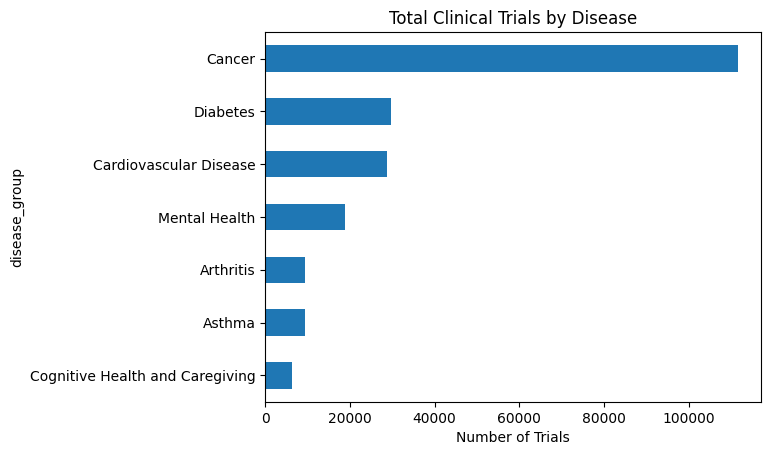

In [ ]:
disease_counts = df.groupby("disease_group")["trial_count"].sum().sort_values()

disease_counts.plot(kind="barh")
plt.title("Total Clinical Trials by Disease")
plt.xlabel("Number of Trials")
plt.show()

Insight: Clinical trial activity is heavily concentrated in oncology, with cancer-related trials far exceeding all other disease categories. Chronic conditions such as arthritis, asthma, and cognitive health receive significantly fewer trials, despite their widespread prevalence.

#### How does clinical trial availability vary across U.S. states? 

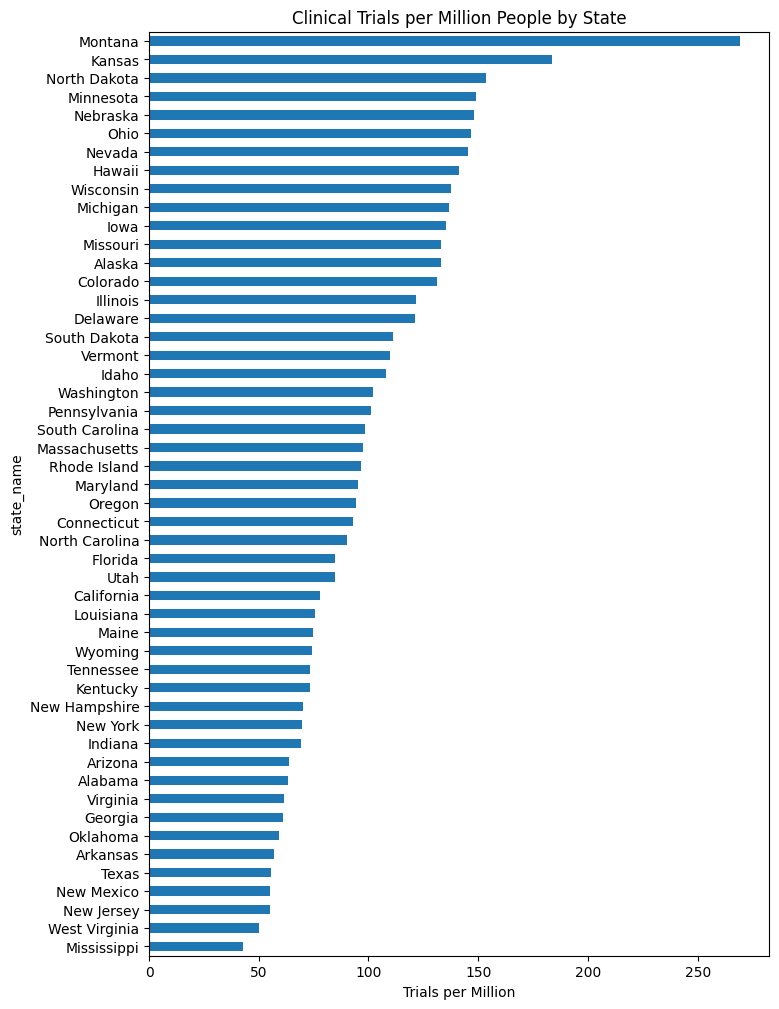

In [44]:
# normalized form
state_density = df.groupby("state_name")["trials_per_million"].mean().sort_values()
state_density.plot(kind="barh", figsize=(8, 12))
plt.title("Clinical Trials per Million People by State")
plt.xlabel("Trials per Million")
plt.show()

Insight: When normalized by population, smaller and less densely populated states exhibit higher clinical trial availability per capita, while some larger or more populous states show relatively lower access.

#### Are regions with higher disease prevalence receiving proportional clinical trial attention?

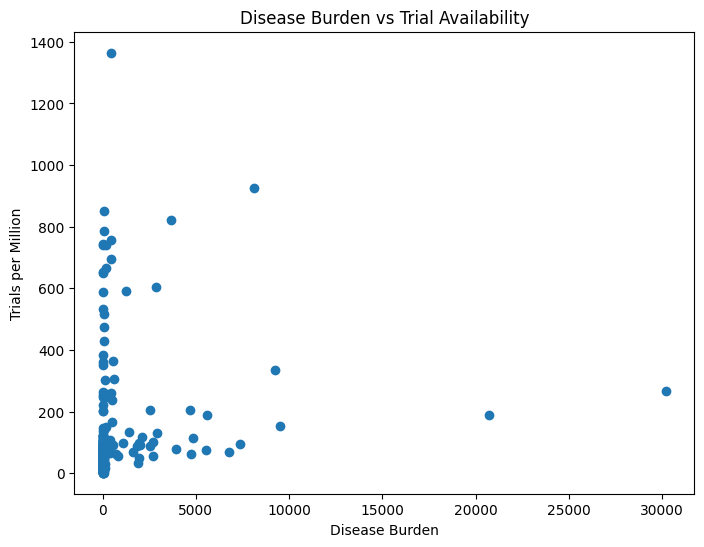

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["burden_value"], df["trials_per_million"])

plt.xlabel("Disease Burden")
plt.ylabel("Trials per Million")
plt.title("Disease Burden vs Trial Availability")

plt.show()

Insight: There is no clear positive relationship between disease burden and clinical trial availability across states, suggesting that trial distribution is not strongly aligned with public health needs.

#### Which diseases show the largest mismatch between prevalence and trial availability? 


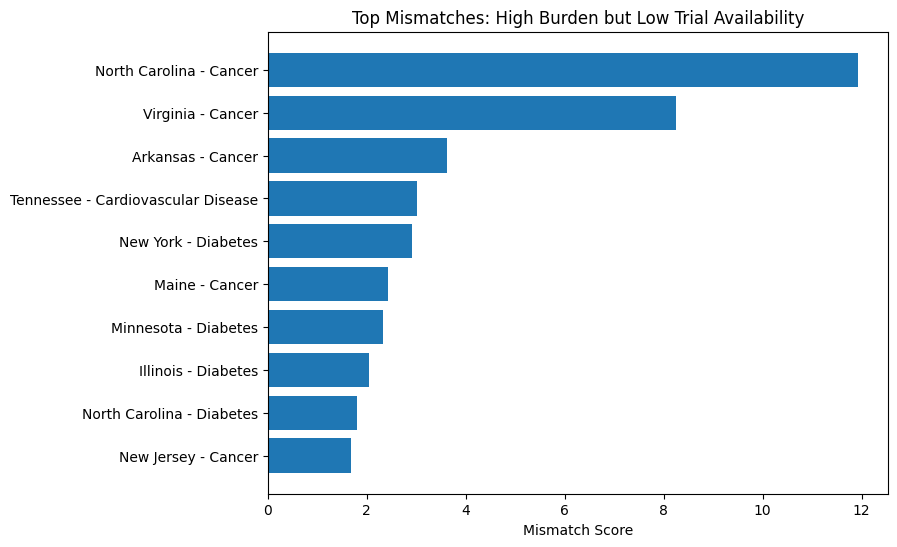

In [46]:
# normalise attributes
df["burden_norm"] = (df["burden_value"] - df["burden_value"].mean()) / df["burden_value"].std()
df["trial_norm"] = (df["trials_per_million"] - df["trials_per_million"].mean()) / df["trials_per_million"].std()
# mismatch score
df["mismatch_score"] = df["burden_norm"] - df["trial_norm"]
# Find biggest mismatches
mismatch = df.sort_values("mismatch_score", ascending=False)
mismatch[["state_name", "disease_group", "mismatch_score"]].head(10)
# Visualize mismatches
top_mismatch = mismatch.head(10)
plt.figure(figsize=(8,6))
plt.barh(top_mismatch["state_name"] + " - " + top_mismatch["disease_group"],
         top_mismatch["mismatch_score"])
plt.title("Top Mismatches: High Burden but Low Trial Availability")
plt.xlabel("Mismatch Score")
plt.gca().invert_yaxis()
plt.show()

Insight: Several states exhibit significant mismatches where high disease burden is not matched by proportional clinical trial availability. Notably, cancer-related burden in states like North Carolina and Virginia shows substantial underrepresentation in clinical trials. These mismatches highlight potential gaps in healthcare research investment and accessibility, indicating that certain regions with high disease burden may be underserved in clinical trial distribution.


**Overall Analysis Conclusion: This analysis reveals significant disparities in clinical trial accessibility across both disease categories and geographic regions in the United States. While oncology dominates clinical research, other high-burden chronic conditions receive comparatively limited attention. Furthermore, the weak relationship between disease burden and trial availability, along with identified state-level mismatches, suggests that clinical research efforts are not optimally aligned with public health needs.**